Using device: cpu
[integral-bundle] loading 'integral_gaussian_L64_N3000_seed20250930.pt'
[integral-bundle] fingerprint: 3db847782db45780f0ecdb1e78a44016989b0855
split sizes | train=2400 val=300 test=300
FNO-1D: 221,889 parameters  (width=64, layers=4, modes=6)

Training FNO-1D
Epoch   1/150 | train 0.007593 | val 0.000595 | t/epoch 2.634s | lr 0.001000
Epoch  10/150 | train 0.000033 | val 0.000051 | t/epoch 2.788s | lr 0.000989
Epoch  20/150 | train 0.000005 | val 0.000005 | t/epoch 3.438s | lr 0.000957
Epoch  30/150 | train 0.000036 | val 0.000014 | t/epoch 2.672s | lr 0.000905
Epoch  40/150 | train 0.000005 | val 0.000003 | t/epoch 2.639s | lr 0.000835
Epoch  50/150 | train 0.000027 | val 0.000054 | t/epoch 2.649s | lr 0.000750
Epoch  60/150 | train 0.000011 | val 0.000003 | t/epoch 3.427s | lr 0.000655
Epoch  70/150 | train 0.000002 | val 0.000004 | t/epoch 2.707s | lr 0.000552
Epoch  80/150 | train 0.000002 | val 0.000003 | t/epoch 2.682s | lr 0.000448
Epoch  90/150 | train 0.0000

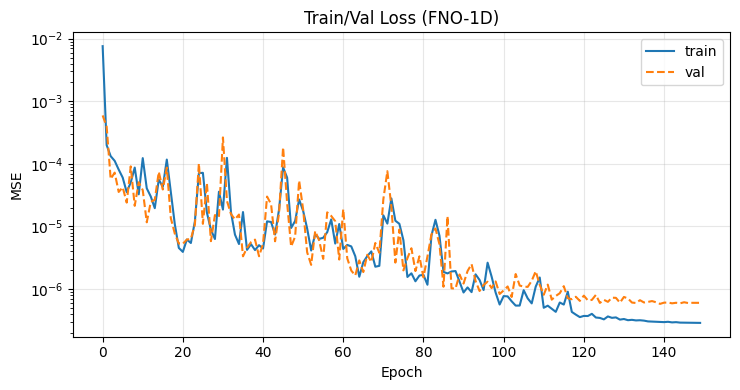

test MSE | FNO-1D: 4.624304e-07


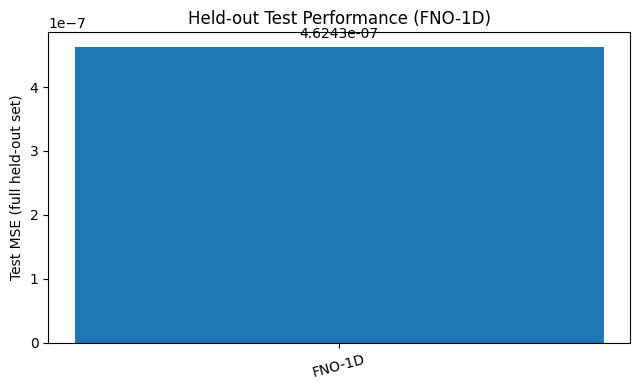


=== Rough FLOPs (per forward, single sample) & Test MSE ===
Model                               FLOPs(est)     FLOPs(M)     Test MSE
FNO-1D                                 1005568        1.006   4.6243e-07

--- Testing at resolution 32 ---
  FNO-1D: 0.046116

--- Testing at resolution 48 ---
  FNO-1D: 0.017005

--- Testing at resolution 64 ---
  FNO-1D: 0.005984

--- Testing at resolution 96 ---
  FNO-1D: 0.016156

--- Testing at resolution 128 ---
  FNO-1D: 0.023400

--- Testing at resolution 256 ---
  FNO-1D: 0.034687


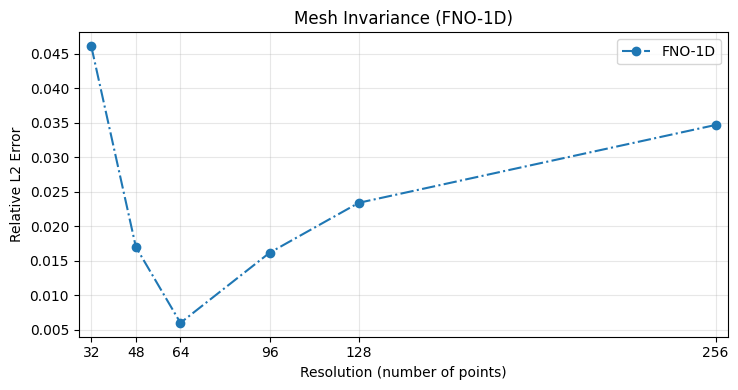

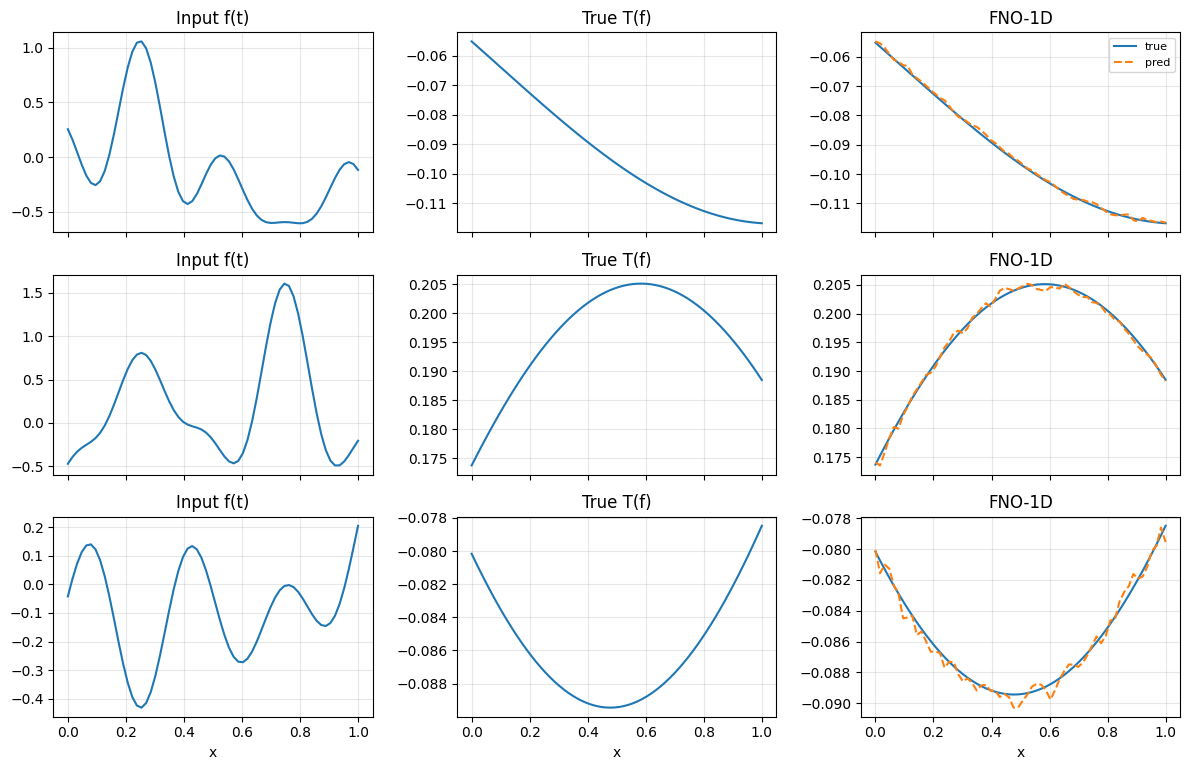

In [ ]:
import time
import math
import os
import hashlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


# Fixed integral-operator data protocol
def eval_integral_basis(coeffs: torch.Tensor, n_points: int) -> torch.Tensor:

    single = coeffs.dim() == 1
    if single:
        coeffs = coeffs.unsqueeze(0)

    coeffs = coeffs.float()
    t = torch.linspace(0.0, 1.0, n_points, dtype=coeffs.dtype, device=coeffs.device)

    f = (
        coeffs[:, 0:1] * torch.sin(2 * math.pi * t)
        + coeffs[:, 1:2] * torch.cos(4 * math.pi * t)
        + coeffs[:, 2:3] * torch.exp(-8 * (t - 0.3) ** 2)
        + coeffs[:, 3:4] * torch.exp(-8 * (t - 0.7) ** 2)
        + coeffs[:, 4:5] * t * (1 - t)
        + coeffs[:, 5:6] * torch.sin(6 * math.pi * t)
        + coeffs[:, 6:7] * (t - 0.5) ** 3
        + coeffs[:, 7:8] * torch.cos(8 * math.pi * t)
    )

    return f.squeeze(0) if single else f


def make_kernel_1d(n_points: int, kernel_type: str = "gaussian", device=None, dtype=torch.float32) -> torch.Tensor:
    x = torch.linspace(0.0, 1.0, n_points, device=device, dtype=dtype)
    t = torch.linspace(0.0, 1.0, n_points, device=device, dtype=dtype)
    X, T = torch.meshgrid(x, t, indexing="ij")

    if kernel_type == "gaussian":
        K = torch.exp(-((X - T) ** 2) / 2)
    elif kernel_type == "exponential":
        K = torch.exp(-5 * torch.abs(X - T))
    elif kernel_type == "polynomial":
        K = (1 + X * T) * torch.exp(-2 * (X - T) ** 2)
    elif kernel_type == "gaussian_narrow":
        sigma = 0.08
        K = torch.exp(-((X - T) ** 2) / (2 * sigma ** 2))
    else:
        raise ValueError(f"Unknown kernel_type: {kernel_type}")

    return K


def apply_integral_operator(f: torch.Tensor, kernel_type: str = "gaussian") -> torch.Tensor:
    """
    Apply T(f)(x) = int_0^1 K(x,t) f(t) dt using trapezoidal quadrature.

    f: (L,) or (N, L)
    return: same leading shape, with length L
    """
    single = f.dim() == 1
    if single:
        f = f.unsqueeze(0)

    f = f.float()
    n_points = f.shape[-1]
    K = make_kernel_1d(n_points, kernel_type, device=f.device, dtype=f.dtype)
    dt = 1.0 / (n_points - 1)

    integrand = K.unsqueeze(0) * f.unsqueeze(1)  # (N, Lx, Lt)
    out = torch.trapz(integrand, dx=dt, dim=2)

    return out.squeeze(0) if single else out


def _bundle_fingerprint(functions: torch.Tensor, first_idxs=(0, 1, 2, 10, 222, 333)):
    h = hashlib.sha1()
    for i in first_idxs:
        if 0 <= i < functions.shape[0]:
            h.update(functions[i].detach().cpu().numpy().astype(np.float32).tobytes())
    return h.hexdigest()


class IntegralBundleDataset(Dataset):

    def __init__(self, bundle: dict, split: str | None = None):
        required = {"coeffs", "functions", "outputs", "n_points", "kernel_type", "splits"}
        missing = required.difference(bundle.keys())
        if missing:
            raise ValueError(
                f"Bundle is missing keys {missing}. "
                "This file may be an old frozen-testset file. Delete it or use a new bundle path."
            )

        self.coeffs = bundle["coeffs"].float()
        self.functions = bundle["functions"].float()
        self.outputs = bundle["outputs"].float()
        self.n_points = int(bundle["n_points"])
        self.kernel_type = str(bundle["kernel_type"])

        if split is None:
            self.indices = torch.arange(len(self.functions))
        else:
            if split not in bundle["splits"]:
                raise ValueError(f"Unknown split {split!r}; expected one of {list(bundle['splits'])}")
            self.indices = bundle["splits"][split].long()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        return self.functions[real_idx], self.outputs[real_idx]

    def get_coeffs(self, idx):
        real_idx = int(self.indices[idx])
        return self.coeffs[real_idx]


def get_or_create_integral_bundle(
    path: str,
    *,
    n_samples: int,
    n_points: int,
    kernel_type: str,
    sample_seed: int,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
):
    """
      train = 2400, val = 300, test = 300
    """
    if os.path.exists(path):
        print(f"[integral-bundle] loading '{path}'")
        bundle = torch.load(path, map_location="cpu")
        if "fingerprint" in bundle:
            print("[integral-bundle] fingerprint:", bundle["fingerprint"])
        return bundle

    print(f"[integral-bundle] creating '{path}'")
    gen = torch.Generator().manual_seed(int(sample_seed))

    coeffs = torch.randn(n_samples, 8, generator=gen) * 0.3
    functions = eval_integral_basis(coeffs, n_points).cpu()
    outputs = apply_integral_operator(functions, kernel_type).cpu()

    split_gen = torch.Generator().manual_seed(int(sample_seed) + 999)
    perm = torch.randperm(n_samples, generator=split_gen)

    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    bundle = {
        "coeffs": coeffs.cpu(),
        "functions": functions.cpu(),
        "outputs": outputs.cpu(),
        "n_points": int(n_points),
        "kernel_type": str(kernel_type),
        "sample_seed": int(sample_seed),
        "splits": {
            "train": train_idx.cpu(),
            "val": val_idx.cpu(),
            "test": test_idx.cpu(),
        },
    }
    bundle["fingerprint"] = _bundle_fingerprint(bundle["functions"])

    torch.save(bundle, path)

    print("[integral-bundle] created")
    print("  train / val / test =", len(train_idx), len(val_idx), len(test_idx))
    print("  fingerprint:", bundle["fingerprint"])
    return bundle


# FNO-1D implementation
class SpectralConv1d(nn.Module):
    """
    1D Fourier layer: multiplication in Fourier space.
    """
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        self.scale = 1 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes, 2)
        )

    def compl_mul1d(self, input, weights):
        # input:   (B, in_channel, modes, 2)
        # weights: (in_channel, out_channel, modes, 2)
        # output:  (B, out_channel, modes, 2)
        return torch.einsum("bixr,ioxr->boxr", input, weights)

    def forward(self, x):
        # x: (B, C, L)
        batch_size = x.shape[0]

        x_ft = torch.fft.rfft(x, dim=-1, norm="ortho")
        x_ft_real = torch.stack([x_ft.real, x_ft.imag], dim=-1)

        n_freq = x.size(-1) // 2 + 1
        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            n_freq,
            2,
            device=x.device,
            dtype=x.dtype,
        )

        m = min(self.modes, n_freq)
        out_ft[:, :, :m] = self.compl_mul1d(
            x_ft_real[:, :, :m],
            self.weights[:, :, :m],
        )

        out_ft_complex = torch.complex(out_ft[..., 0], out_ft[..., 1])
        x_out = torch.fft.irfft(out_ft_complex, n=x.size(-1), dim=-1, norm="ortho")
        return x_out


class FNO1d(nn.Module):
    """
    Fourier Neural Operator for 1D functions.
    """
    def __init__(self, modes, width, n_layers=4, input_dim=1, output_dim=1, pad: int = 0):
        super().__init__()
        self.modes = modes
        self.width = width
        self.n_layers = n_layers
        self.pad = pad

        self.fc0 = nn.Linear(input_dim + 1, self.width)

        self.conv_layers = nn.ModuleList()
        self.w_layers = nn.ModuleList()
        for _ in range(self.n_layers):
            self.conv_layers.append(SpectralConv1d(self.width, self.width, self.modes))
            self.w_layers.append(nn.Conv1d(self.width, self.width, 1))

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        B, L = x.shape
        grid = torch.linspace(0, 1, L, device=x.device).repeat(B, 1)

        x = torch.stack([x, grid], dim=-1)
        x = self.fc0(x).permute(0, 2, 1)  # (B, C, L)

        if self.pad > 0:
            x = F.pad(x, (0, self.pad))

        for i in range(self.n_layers):
            x1 = self.conv_layers[i](x)
            x2 = self.w_layers[i](x)
            x = x1 + x2
            if i < self.n_layers - 1:
                x = F.relu(x)

        if self.pad > 0:
            x = x[..., :L]

        x = x.permute(0, 2, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)


# Training / eval utilities
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    for f, y in loader:
        f, y = f.to(device), y.to(device)
        optimizer.zero_grad()
        yhat = model(f)
        loss = criterion(yhat, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
    return running / max(1, len(loader))


def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for f, y in loader:
            f, y = f.to(device), y.to(device)
            yhat = model(f)
            total += criterion(yhat, y).item()
    return total / max(1, len(loader))


def evaluate_full_dataset(model, loader, device="cpu"):

    model.eval()
    se_sum = 0.0
    count = 0

    with torch.no_grad():
        for f, y in loader:
            f = f.to(device)
            y = y.to(device)
            yhat = model(f)

            se_sum += F.mse_loss(yhat, y, reduction="sum").item()
            count += y.numel()

    return se_sum / max(count, 1)


def train_model(model, train_loader, val_loader, epochs=150, lr=1e-3, device="cpu"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    hist = {"train_loss": [], "val_loss": [], "epoch_time": [], "lr": []}

    for ep in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        dt = time.perf_counter() - t0

        hist["train_loss"].append(tr)
        hist["val_loss"].append(va)
        hist["epoch_time"].append(dt)
        hist["lr"].append(optimizer.param_groups[0]["lr"])

        if ep % 10 == 0 or ep == 1:
            print(
                f"Epoch {ep:3d}/{epochs} | train {tr:.6f} | val {va:.6f} "
                f"| t/epoch {dt:.3f}s | lr {hist['lr'][-1]:.6f}"
            )

    return hist


# Plot helpers
def plot_train_val(hist):
    plt.figure(figsize=(7.5, 4))
    plt.plot(hist["train_loss"], label="train")
    plt.plot(hist["val_loss"], label="val", linestyle="--")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Train/Val Loss (FNO-1D)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def bar_test_mse(results):
    names = list(results.keys())
    vals = [results[n] for n in names]
    plt.figure(figsize=(6.5, 4))
    plt.bar(names, vals)
    for i, v in enumerate(vals):
        plt.text(i, v * 1.02, f"{v:.4e}", ha="center", va="bottom")
    plt.ylabel("Test MSE (full held-out set)")
    plt.title("Held-out Test Performance (FNO-1D)")
    plt.xticks(rotation=15)
    plt.tight_layout()


def plot_test_examples(models_or_model, dataset, n_show=4, device="cpu", idxs=None, seed=12345):
    if isinstance(models_or_model, dict):
        models = models_or_model
    else:
        models = {"FNO-1D": models_or_model}

    if idxs is None:
        rng = np.random.default_rng(seed)
        idxs = rng.choice(len(dataset), n_show, replace=False)
    else:
        idxs = list(idxs)

    fig, axes = plt.subplots(
        n_show,
        len(models) + 2,
        figsize=(4 * (len(models) + 2), 2.6 * n_show),
        sharex=True,
    )
    if n_show == 1:
        axes = axes.reshape(1, -1)

    xs = torch.linspace(0, 1, dataset.n_points)

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            f, y = dataset[int(idx)]
            axes[i, 0].plot(xs, f)
            axes[i, 0].set_title("Input f(t)")
            axes[i, 0].grid(True, alpha=0.3)

            axes[i, 1].plot(xs, y)
            axes[i, 1].set_title("True T(f)")
            axes[i, 1].grid(True, alpha=0.3)

            for j, (name, model) in enumerate(models.items(), start=2):
                yhat = model(f.unsqueeze(0).to(device)).squeeze(0).cpu()
                axes[i, j].plot(xs, y, label="true")
                axes[i, j].plot(xs, yhat, linestyle="--", label="pred")
                axes[i, j].set_title(name)
                axes[i, j].grid(True, alpha=0.3)
                if i == 0:
                    axes[i, j].legend(fontsize=8)

    for k in range(len(models) + 2):
        axes[-1, k].set_xlabel("x")
    plt.tight_layout()


# Mesh-invariance utilities
def relative_l2_weighted(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> float:
    L = pred.numel()
    dx = 1.0 / max(1, L - 1)
    w = pred.new_ones(L)
    if L > 1:
        w[0] = 0.5
        w[-1] = 0.5

    def weighted_norm(z):
        return torch.sqrt(((z ** 2) * w).sum() * dx)

    den = weighted_norm(target)
    num = weighted_norm(pred - target)
    return (num if den < eps else num / (den + eps)).item()


def mesh_invariance_from_coeffs_fno(
    model,
    test_dataset: IntegralBundleDataset,
    kernel_type: str,
    grid_list,
    n_per_res: int,
    device,
    batch_size: int = 32,
):

    n_use = min(n_per_res, len(test_dataset))
    coeffs = torch.stack([test_dataset.get_coeffs(i) for i in range(n_use)]).cpu()

    results = []
    for n_points in grid_list:
        print(f"\n--- Testing at resolution {n_points} ---")

        f_test = eval_integral_basis(coeffs, n_points).cpu()
        y_true = apply_integral_operator(f_test, kernel_type).cpu()

        errs = []
        model.eval()

        with torch.no_grad():
            for start in range(0, n_use, batch_size):
                end = min(start + batch_size, n_use)
                f_batch = f_test[start:end].to(device)
                pred_batch = model(f_batch).cpu()

                for pred, target in zip(pred_batch, y_true[start:end]):
                    errs.append(relative_l2_weighted(pred, target))

        avg_err = float(np.mean(errs))
        results.append(avg_err)
        print(f"  FNO-1D: {avg_err:.6f}")

    return results


def plot_mesh_invariance(grid_list, vals, title="Mesh Invariance (FNO-1D)"):
    plt.figure(figsize=(7.5, 4))
    plt.plot(grid_list, vals, marker="o", linestyle="-.", label="FNO-1D")
    plt.xlabel("Resolution (number of points)")
    plt.ylabel("Relative L2 Error")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(grid_list, [str(x) for x in grid_list])
    plt.margins(x=0.02)
    plt.tight_layout()


# FLOPs estimator
def macs_fno1d(seq_len: int, width: int, n_layers: int, n_modes: int) -> float:
    # Very rough proxy.
    c1, c2 = 8.0, 2.0
    per_layer = (
        c1 * width * seq_len * max(1, math.log2(max(2, seq_len)))
        + c2 * (width ** 2) * n_modes
        + width * seq_len
    )
    macs = n_layers * per_layer + width * seq_len + width * seq_len // 2
    return float(macs)


def print_macs_table(model_name: str, seq_len: int, width: int, n_layers: int, n_modes: int, test_mse: float):
    macs = macs_fno1d(seq_len, width, n_layers, n_modes)
    print("\n=== Rough FLOPs (per forward, single sample) & Test MSE ===")
    print(f"{'Model':30s} {'FLOPs(est)':>15s} {'FLOPs(M)':>12s} {'Test MSE':>12s}")
    print(f"{model_name:30s} {macs:15.0f} {macs / 1e6:12.3f} {test_mse:12.4e}")


# Main
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # ---- Data ----
    N_SAMPLES = 3000
    N_POINTS = 64
    KERNEL = "gaussian"  # "gaussian" | "exponential" | "polynomial" | "gaussian_narrow"
    BATCH = 32
    SEED = 20250930

    BUNDLE_PATH = f"integral_{KERNEL}_L{N_POINTS}_N{N_SAMPLES}_seed{SEED}.pt"

    bundle = get_or_create_integral_bundle(
        BUNDLE_PATH,
        n_samples=N_SAMPLES,
        n_points=N_POINTS,
        kernel_type=KERNEL,
        sample_seed=SEED,
        train_ratio=0.8,
        val_ratio=0.1,
    )

    train_ds = IntegralBundleDataset(bundle, split="train")
    val_ds = IntegralBundleDataset(bundle, split="val")
    test_ds = IntegralBundleDataset(bundle, split="test")

    print(f"split sizes | train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

    # ---- Model ----
    WIDTH = 64
    N_LAYERS = 4
    N_MODES = 6

    model = FNO1d(
        modes=N_MODES,
        width=WIDTH,
        n_layers=N_LAYERS,
        input_dim=1,
        output_dim=1,
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"FNO-1D: {n_params:,} parameters  (width={WIDTH}, layers={N_LAYERS}, modes={N_MODES})")

    # ---- Train ----
    print("\n" + "=" * 60)
    print("Training FNO-1D")
    print("=" * 60)
    hist = train_model(model, train_loader, val_loader, epochs=150, lr=1e-3, device=device)
    plot_train_val(hist)
    plt.show()

    # Held-out evaluation: full fixed test set
    mse = evaluate_full_dataset(model, test_loader, device=device)
    print(f"test MSE | FNO-1D: {mse:.6e}")

    bar_test_mse({"FNO-1D": mse})
    plt.show()

    # FLOPs
    print_macs_table(
        "FNO-1D",
        seq_len=N_POINTS,
        width=model.width,
        n_layers=model.n_layers,
        n_modes=model.modes,
        test_mse=mse,
    )

    # Mesh invariance: same held-out continuous functions across resolutions
    RES_LIST = [32, 48, 64, 96, 128, 256]
    mi_vals = mesh_invariance_from_coeffs_fno(
        model,
        test_dataset=test_ds,
        kernel_type=KERNEL,
        grid_list=RES_LIST,
        n_per_res=100,
        device=device,
        batch_size=BATCH,
    )
    plot_mesh_invariance(RES_LIST, mi_vals, title="Mesh Invariance (FNO-1D)")
    plt.show()

    # Qualitative examples
    plot_test_examples(model, test_ds, n_show=3, device=device, idxs=[10, 30, 150])
    plt.show()


In [ ]:
def plot_mesh_invariance(grid_list, vals, title='Mesh Invariance (FNO-1D)'):
    plt.figure(figsize=(7.5,4))
    plt.plot(grid_list, vals, marker='o', linestyle='-.', label='FNO-1D')
    plt.xlabel('Resolution (number of points)'); plt.ylabel('Relative L2 Error')
    plt.yscale("log")
    plt.title(title); plt.grid(True, alpha=0.3); plt.legend()
    plt.xticks(grid_list, [str(x) for x in grid_list]); plt.margins(x=0.02); plt.tight_layout()


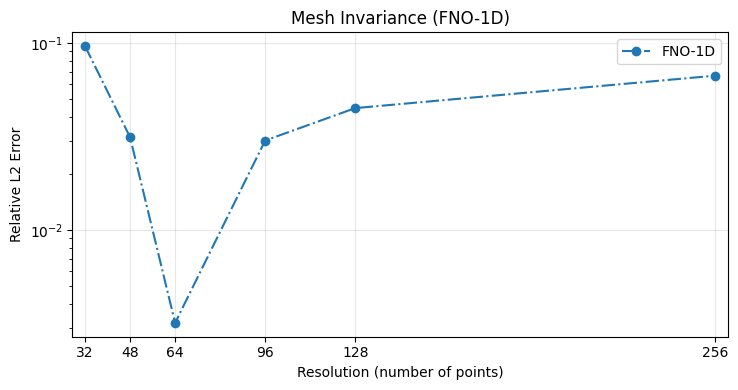

In [ ]:
plot_mesh_invariance(RES_LIST, mi_vals); plt.show()

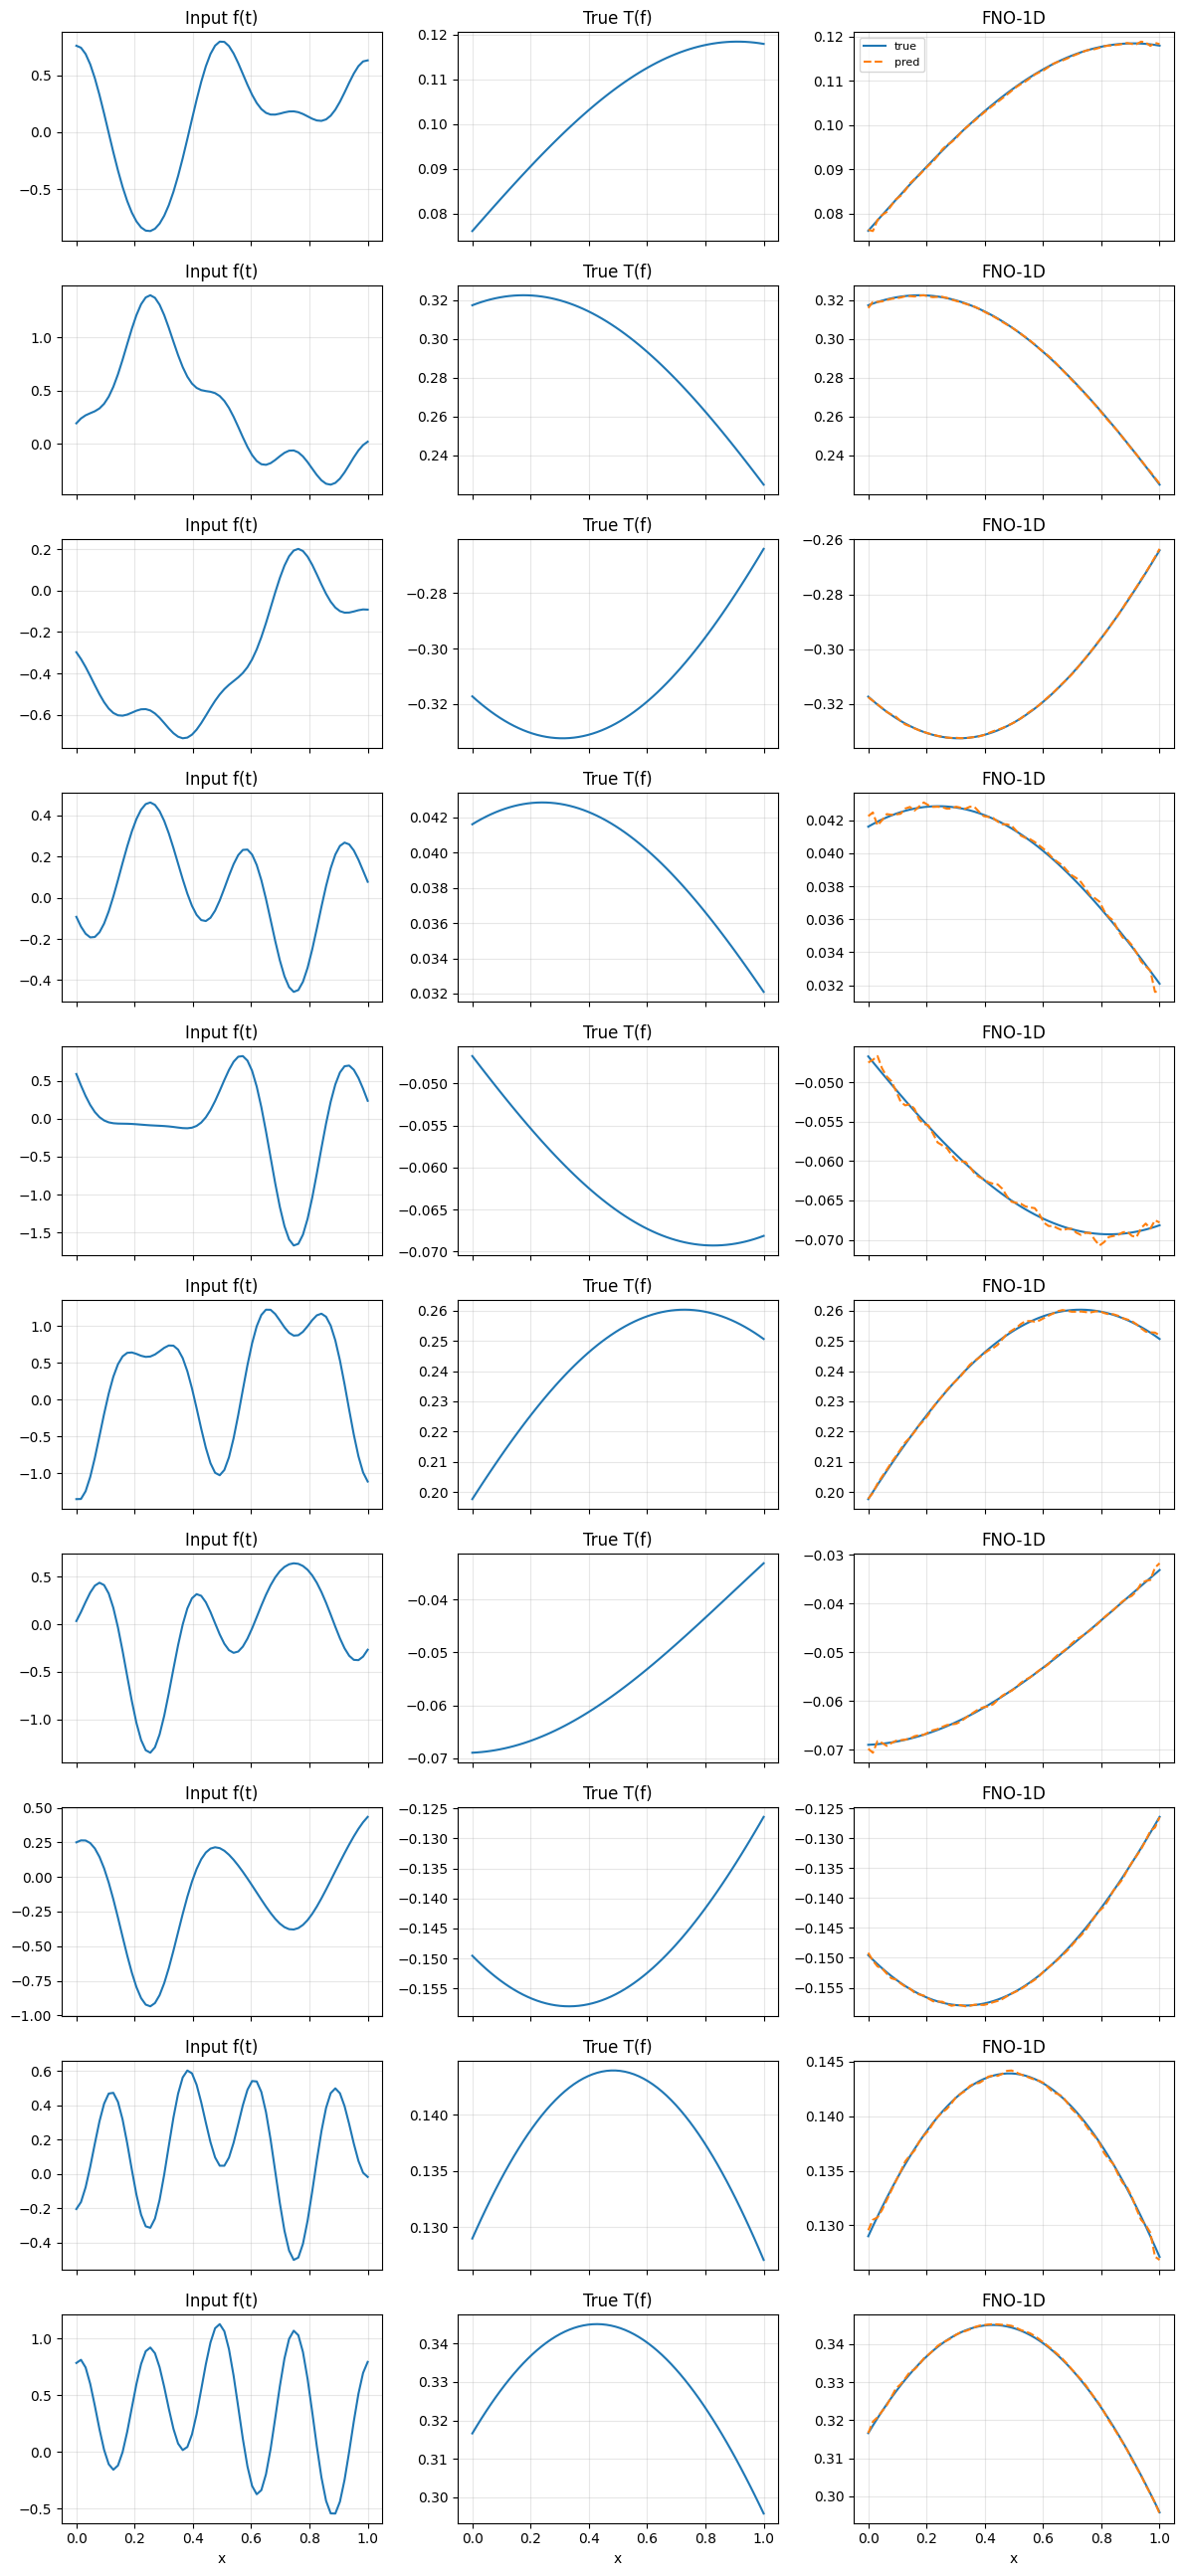

In [ ]:
plot_test_examples(model, test_ds, n_show=10, device=device, idxs=[238,
256,
276,
15,
69,
190,
59,
293,
298,
79])
plt.show()